# Phase 6: Predictive Machine Learning Pipeline
In this phase, we transition from observing the dataset to actively predicting outcomes. Due to the extreme class imbalance in Postpartum Depression (95% positive), we will train our models to predict maternal **Anxiety Risk (HADS-A)**, which features a balanced 52/22/25 Normal/Borderline/Abnormal split.

Our pipeline consists of:
1. **Feature Engineering & Selection:** Identifying the most powerful predictive variables using Random Forest.
2. **Hyperparameter Tuning:** Using GridSearchCV to find the optimal mathematical settings.
3. **Model Evaluation:** Comparing an interpretable **Decision Tree**, a robust **Random Forest**, and an optimized **XGBoost** classifier.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, accuracy_score

import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

# 1. Load Data
try:
    df = pd.read_csv('data/Dataset_Featured.csv')
    print(f"Data successfully loaded. Shape: {df.shape}")
except FileNotFoundError:
    print('Dataset_Featured.csv missing. Please run p4_feature_engineering.ipynb first.')


Data successfully loaded. Shape: (410, 64)


### 1. Data Preparation
Machine Learning algorithms cannot understand text. We must mathematically encode categorical text into integers, and drop variables that represent "answers" (data leakage) so the AI learns from the predictors, not the test results.

In [7]:
# Drop Clinical Targets (we cannot use PTSD/PPD to predict Anxiety, that is cheating)
drop_leakage_cols = ['epds_total', 'hads_a_total', 'cbts_total', 'cbts_birth_ptsd', 'cbts_general_ptsd', 'ppd_risk']
if 'participant_number' in df.columns.str.lower():
    df = df.drop(columns=[c for c in df.columns if 'participant' in c.lower()])
    
X_raw = df.drop(columns=drop_leakage_cols + ['anxiety_risk']).copy()
y_raw = df['anxiety_risk'].copy()

# Label Encode the Target (Normal=0, Borderline=1, Abnormal=2)
le = LabelEncoder()
y = le.fit_transform(y_raw)
print(f"Target Mapping: {dict(zip(le.classes_, le.transform(le.classes_)))}")

# One-Hot Encode Categorical Demographics
X = pd.get_dummies(X_raw, drop_first=True)

# Train/Test Split (80% Training, 20% Unseen Testing Data)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Training instances: {X_train.shape[0]} | Features: {X_train.shape[1]}")


Target Mapping: {'Abnormal': np.int64(0), 'Borderline': np.int64(1), 'Normal': np.int64(2)}
Training instances: 328 | Features: 65


### 2. Feature Selection (Top 15 Features)
Instead of feeding the AI 80+ columns, we use a baseline Random Forest to calculate the mathematical "Gini Importance" of every single question. We filter our dataset to only use the top features.

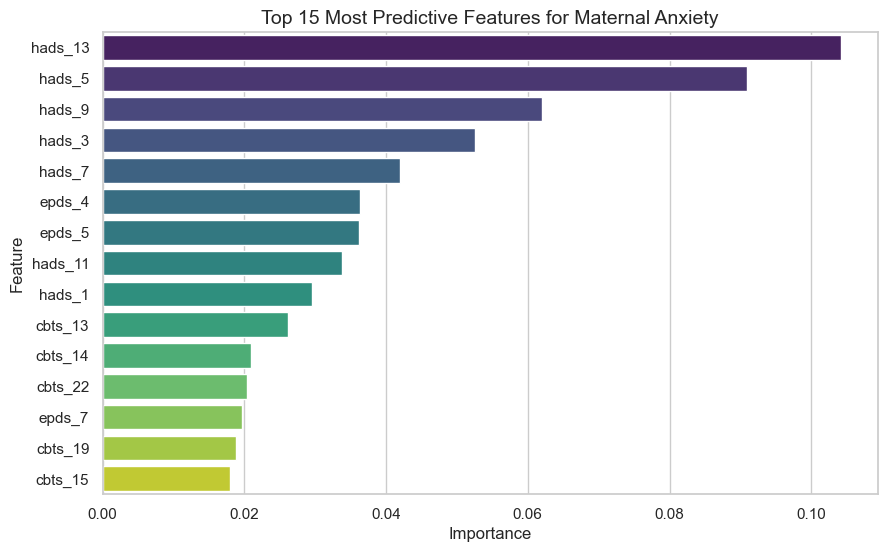

Dataset mathematically trimmed to 15 optimal features.


In [8]:
# Initialize a baseline Random Forest to test feature value
rf_selector = RandomForestClassifier(n_estimators=100, random_state=42)
rf_selector.fit(X_train, y_train)

# Extract and sort feature importances
importances = rf_selector.feature_importances_
feat_imp_df = pd.DataFrame({'Feature': X_train.columns, 'Importance': importances}).sort_values('Importance', ascending=False)

# Plot the Top 15 Features
plt.figure(figsize=(10, 6))
sns.barplot(data=feat_imp_df.head(15), x='Importance', y='Feature', palette='viridis')
plt.title('Top 15 Most Predictive Features for Maternal Anxiety', fontsize=14)
plt.show()

# Extract Top 15
top_features = feat_imp_df.head(15)['Feature'].tolist()
X_train_top = X_train[top_features]
X_test_top = X_test[top_features]
print(f"Dataset mathematically trimmed to {len(top_features)} optimal features.")


### 3. Hyperparameter Tuning (GridSearch)
We use 5-Fold Cross Validation to find the optimal settings for our Decision Tree, preventing it from overfitting into an unreadable mess.

In [9]:
# GridSearch for the highly visual Decision Tree
tree_grid = {
    'max_depth': [3, 4, 5, 6],
    'min_samples_split': [2, 5, 10],
    'criterion': ['gini', 'entropy']
}

dt_base = DecisionTreeClassifier(random_state=42)
dt_grid_search = GridSearchCV(estimator=dt_base, param_grid=tree_grid, cv=5, scoring='accuracy', n_jobs=-1)
dt_grid_search.fit(X_train_top, y_train)

best_dt = dt_grid_search.best_estimator_
print(f"Optimal Decision Tree Settings Locked:\n{dt_grid_search.best_params_}")


Optimal Decision Tree Settings Locked:
{'criterion': 'gini', 'max_depth': 6, 'min_samples_split': 5}


### 4. Model Training: Random Forest & XGBoost Champion
We train massive ensemble models to test our absolute ceiling for predictive accuracy.

In [10]:
# Train Random Forest baseline on Top 15
rf_model = RandomForestClassifier(n_estimators=200, max_depth=6, random_state=42)
rf_model.fit(X_train_top, y_train)

# Train XGBoost on Top 15
xgb_model = XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=4, random_state=42, eval_metric='mlogloss')
xgb_model.fit(X_train_top, y_train)

# Evaluate the 3 Models
models = {
    'Tuned Decision Tree': best_dt,
    'Random Forest': rf_model,
    'XGBoost': xgb_model
}

for name, model in models.items():
    y_pred = model.predict(X_test_top)
    acc = accuracy_score(y_test, y_pred)
    print(f"--- {name} Accuracy: {acc*100:.1f}% ---")
    
# Display full report for XGBoost
print("\nDetailed XGBoost Report:")
print(classification_report(y_test, xgb_model.predict(X_test_top), target_names=le.classes_))


--- Tuned Decision Tree Accuracy: 78.0% ---
--- Random Forest Accuracy: 87.8% ---
--- XGBoost Accuracy: 86.6% ---

Detailed XGBoost Report:
              precision    recall  f1-score   support

    Abnormal       0.95      0.86      0.90        21
  Borderline       0.71      0.67      0.69        18
      Normal       0.89      0.95      0.92        43

    accuracy                           0.87        82
   macro avg       0.85      0.83      0.84        82
weighted avg       0.86      0.87      0.86        82



In [11]:
# Display full report for XGBoost
print("\nDetailed RandomForest Report:")
print(classification_report(y_test, rf_model.predict(X_test_top), target_names=le.classes_))


Detailed RandomForest Report:
              precision    recall  f1-score   support

    Abnormal       0.95      0.90      0.93        21
  Borderline       0.75      0.67      0.71        18
      Normal       0.89      0.95      0.92        43

    accuracy                           0.88        82
   macro avg       0.86      0.84      0.85        82
weighted avg       0.88      0.88      0.88        82



### 5. Interpreting the AI (Decision Tree Visualization)
We physically draw the mathematical flowchart the Tuned Decision Tree uses to diagnose the mothers.

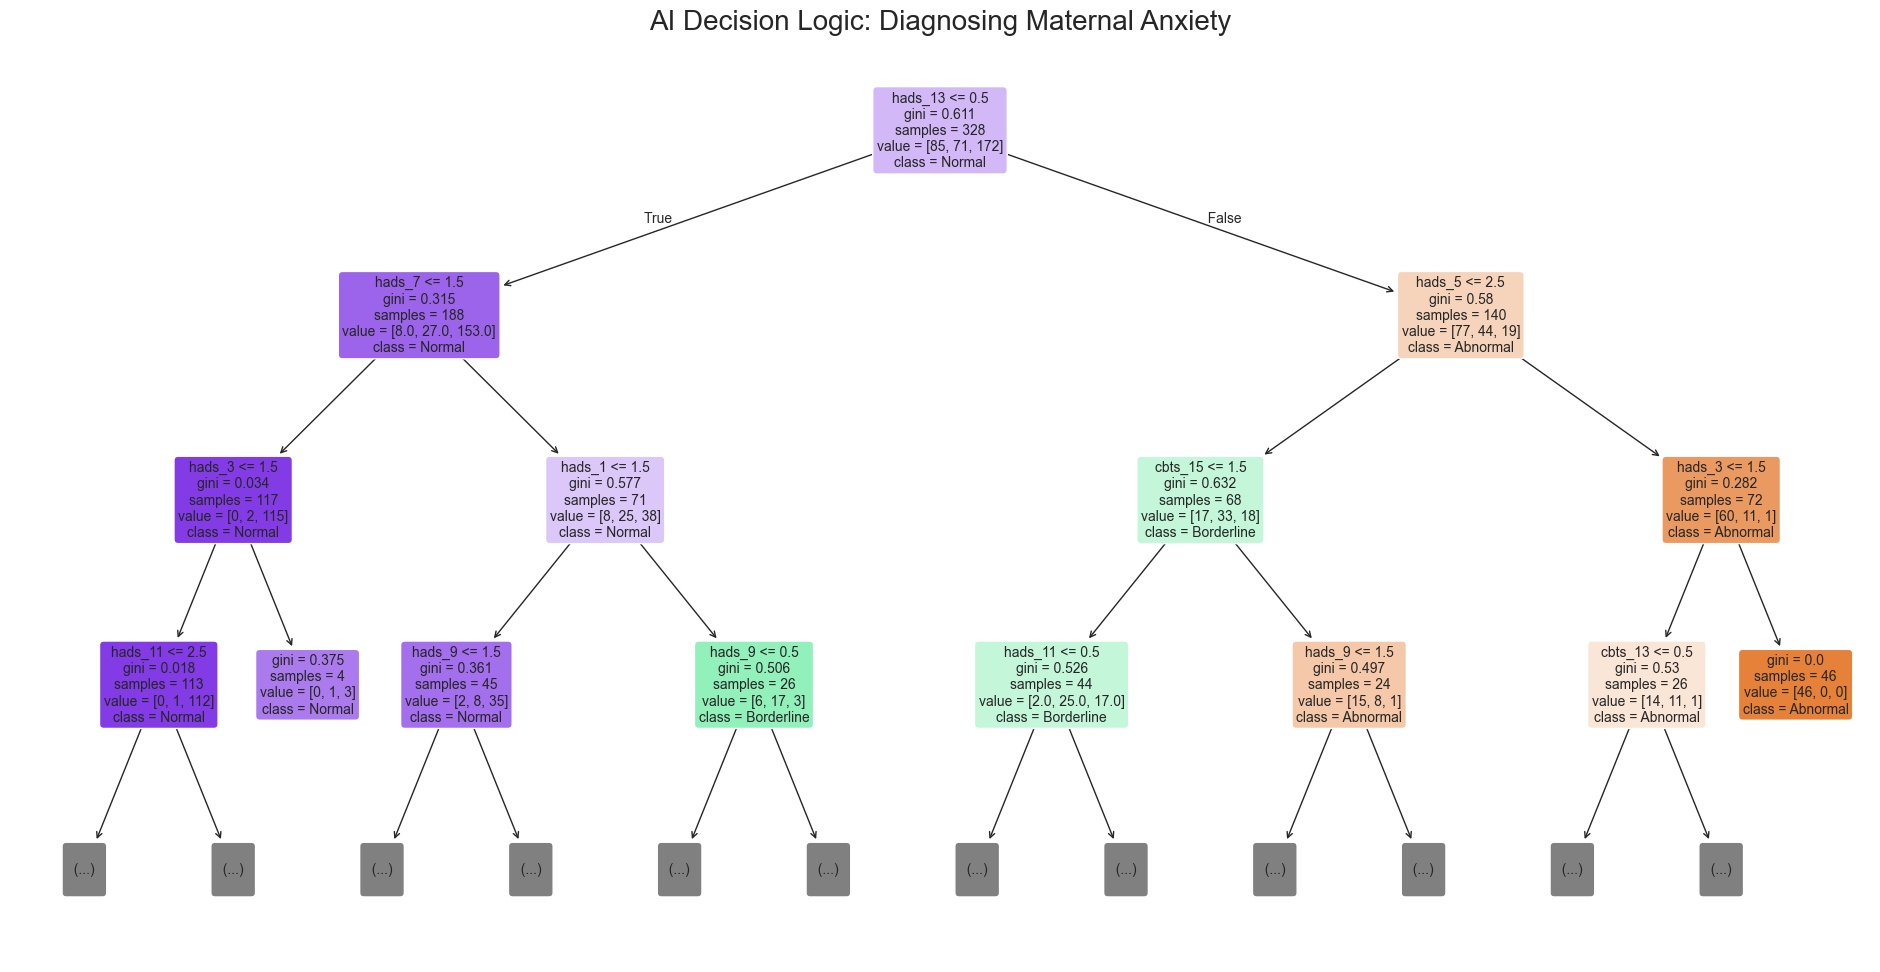

In [12]:
plt.figure(figsize=(24, 12))
plot_tree(
    best_dt, 
    feature_names=top_features, 
    class_names=le.classes_, 
    filled=True, 
    rounded=True, 
    fontsize=10,
    max_depth=3 # Limit visual depth so text is readable
)
plt.title('AI Decision Logic: Diagnosing Maternal Anxiety', fontsize=20)
plt.show()


In [13]:
import pickle

In [14]:
with open("rf_model.pkl", "wb") as file:
    pickle.dump(rf_model, file)